In [4]:
import pandas as pd

df = pd.read_csv("../logs/agv_battery_log.csv")

print(df.head())

   agv_id      time        soc   battery  status
0       1  0.004762  79.992133  497.2311  MOVING
1       1  0.009524  79.984266  497.1822  MOVING
2       1  0.014286  79.976400  497.1333  MOVING
3       1  0.019048  79.968533  497.0844  MOVING
4       1  0.023810  79.960666  497.0355  MOVING


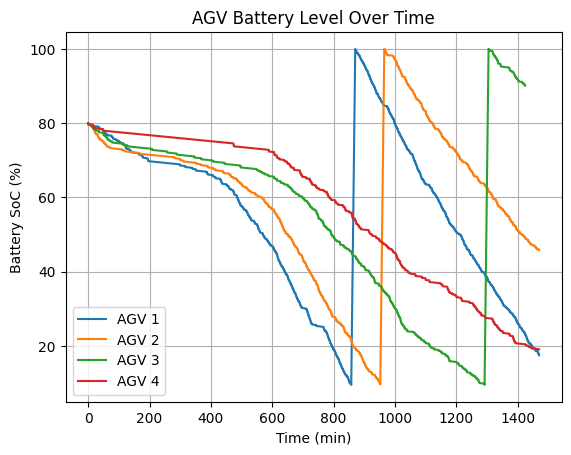

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../logs/agv_battery_log.csv")

for agv_id in df["agv_id"].unique():
    agv = df[df["agv_id"] == agv_id]
    plt.plot(agv["time"], agv["soc"], label=f"AGV {agv_id}")

plt.xlabel("Time (min)")
plt.ylabel("Battery SoC (%)")
plt.title("AGV Battery Level Over Time")
plt.legend()
plt.grid(True)
plt.show()

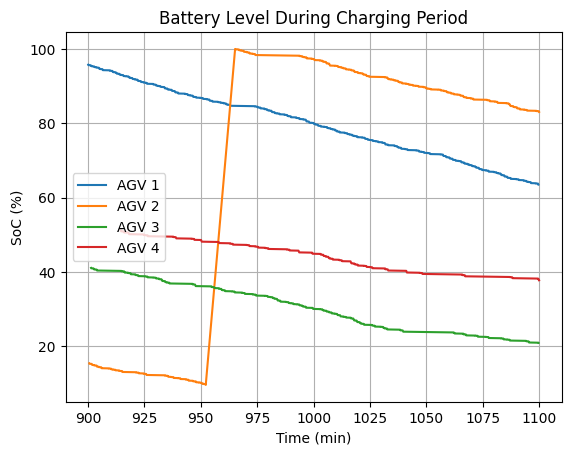

In [6]:
df_zoom = df[(df["time"] >= 900) & (df["time"] <= 1100)]

for agv_id in df_zoom["agv_id"].unique():

    agv = df_zoom[df_zoom["agv_id"] == agv_id]

    plt.plot(agv["time"], agv["soc"], label=f"AGV {agv_id}")

plt.xlabel("Time (min)")

plt.ylabel("SoC (%)")

plt.title("Battery Level During Charging Period")

plt.legend()

plt.grid(True)

plt.show()

In [12]:
agv2_charging = df[
    (df["agv_id"] == 2) &
    (df["time"] >= 950) &
    (df["time"] <= 975) &
    (df["status"] == "CHARGING")
]

print(agv2_charging)

       agv_id        time         soc     battery    status
27745       2  952.118225    9.758723   60.660224  CHARGING
27746       2  952.122987    9.750856   60.611324  CHARGING
27747       2  952.127749    9.742990   60.562424  CHARGING
27748       2  952.132511    9.735123   60.513524  CHARGING
27749       2  952.137273    9.727256   60.464624  CHARGING
27750       2  952.142034    9.719389   60.415724  CHARGING
27751       2  952.146796    9.711523   60.366824  CHARGING
27752       2  952.151558    9.703656   60.317924  CHARGING
27753       2  952.156320    9.695789   60.269024  CHARGING
27754       2  952.161082    9.687922   60.220124  CHARGING
27755       2  952.165844    9.680055   60.171224  CHARGING
27756       2  952.170606    9.672189   60.122324  CHARGING
27757       2  952.175368    9.664322   60.073424  CHARGING
27758       2  952.180130    9.656455   60.024524  CHARGING
27759       2  952.184892    9.648588   59.975624  CHARGING
27760       2  952.189654    9.640721   

In [11]:

agv_id = 2

agv = df[df["agv_id"] == agv_id].sort_values("time")

first_charging_idx = agv[agv["status"] == "CHARGING"].index[0]

before = agv.loc[:first_charging_idx].iloc[-2:-1]
during = agv.loc[[first_charging_idx]]

first_after_idx = agv[
    (agv.index > first_charging_idx) &
    (agv["status"] != "CHARGING")
].index[0]

after = agv.loc[[first_after_idx]]

verification = pd.concat([before, during, after])

print(verification[["agv_id", "time", "soc", "battery","soc","status"]])


       agv_id        time        soc     battery        soc    status
27744       2  952.113463   9.766590   60.709124   9.766590      IDLE
27745       2  952.118225   9.758723   60.660224   9.758723  CHARGING
27763       2  965.211041  99.992133  621.551100  99.992133    MOVING


In [2]:
import pandas as pd

df = pd.read_csv("../logs/agv_trip_log.csv")

agv2_task = df[

    (df["agv_id"] == 2) &

    (df["time"] >= 2.10) &

    (df["time"] <= 2.18)

]

agv2_task[["time", "event", "node", "payload_kg", "items_loaded", "battery_wh", "status"]]

,time,event,node,payload_kg,items_loaded,battery_wh,status
102,2.133333,Pickup completed,200,0.32,1,493.961648,LOADING
103,2.138095,Edge traversed,200,0.32,1,493.912716,MOVING
104,2.142857,Edge traversed,172,0.32,1,493.863784,MOVING
105,2.147619,Edge traversed,144,0.32,1,493.814852,MOVING
106,2.152381,Edge traversed,116,0.32,1,493.765920,MOVING
107,2.157143,Edge traversed,117,0.32,1,493.716988,MOVING
108,2.161905,Edge traversed,118,0.32,1,493.668056,MOVING
109,2.166667,Edge traversed,119,0.32,1,493.619124,MOVING
110,2.171429,Edge traversed,120,0.32,1,493.570192,MOVING
111,2.171429,Arrived at server,121,0.32,1,493.570192,MOVING


In [3]:
df = pd.read_csv("../logs/agv_trip_log.csv")

selection = df[

    (df["agv_id"] == 2) &

    (df["time"] >= 7.05) &

    (df["time"] <= 7.13)

]

selection[["time", "event", "node", "payload_kg", "items_loaded", "battery_wh", "status"]]

,time,event,node,payload_kg,items_loaded,battery_wh,status
159,7.100000,Pickup completed,207,0.1,1,491.036654,LOADING
160,7.104762,Edge traversed,207,0.1,1,490.987744,MOVING
161,7.109524,Edge traversed,179,0.1,1,490.938834,MOVING
162,7.114286,Edge traversed,151,0.1,1,490.889924,MOVING
163,7.119048,Edge traversed,123,0.1,1,490.841014,MOVING
164,7.123810,Edge traversed,122,0.1,1,490.792104,MOVING
165,7.123810,Arrived at server,121,0.1,1,490.792104,MOVING
